# Generative Models

# STUDENT --> CRISTIAN ANDRÉS CÓRDOBA SILVESTRE (DNI: 05988721G)

<figure>
    <img src="https://drive.google.com/uc?export=view&id=1UjunyOkHxHewQ51X75Edq8VYlQshNyRr" alt="Picture" style="display: block; margin: 0 auto;" />
    <figcaption style="text-align: center;"><strong>Fig. 1: Face Generation using GAN. Source: <a href="https://www.eff.org/files/2018/02/20/malicious_ai_report_final.pdf">https://www.eff.org/files/2018/02/20/malicious_ai_report_final.pdf</a></strong></figcaption>
</figure>



## Imports of the project

In [ ]:
import os
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import tensorflow as tf

from sklearn.manifold import TSNE
from scipy.stats import norm

## Auxiliary functions

In [ ]:
class Reshape(nn.Module):
    def __init__(self, *args):
        super(Reshape, self).__init__()
        self.shape = args

    def forward(self, x):
        return x.view(x.size(0), *self.shape)


def generate_noise(batch_size, noise_dim):
    return torch.randn(batch_size, noise_dim, 1, 1).to(device)

def generate_images(generator, title="Generated Images", noise_dim=100, tanh_output=True):
    noise = generate_noise(25, noise_dim)

    was_training = generator.training
    generator.eval()

    with torch.no_grad():
        generated_images = generator(noise)

    if tanh_output:
        generated_images = (generated_images + 1.0) / 2.0  # map [-1, 1] -> [0, 1]

    generated_images = generated_images.view(25, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(5, 5, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i], cmap='gray')
        ax.axis('off')

    plt.suptitle(title)
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

    if was_training:
        generator.train()


def plot_images(rows, cols, images, title):
    """Displays images in a grid."""
    images = images.reshape(rows, cols, 28, 28)
    grid = np.zeros(shape=(rows * 28, cols * 28))

    for i in range(rows):
        for j in range(cols):
            grid[i * 28:(i + 1) * 28, j * 28:(j + 1) * 28] = images[i, j]

    plt.figure(figsize=(10, 10))
    plt.imshow(grid, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()


def plot_loss_curves(losses_g, losses_d, title="GAN Loss Curves"):
    plt.figure(figsize=(8, 5))
    plt.plot(losses_g, label="Generator Loss")
    plt.plot(losses_d, label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

We load the MNIST dataset

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = datasets.MNIST(root='MNIST_data/', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='MNIST_data/', train=False, download=True, transform=transform)

# Optional subset for faster testing
# trainset = Subset(trainset, range(0, len(trainset)//10))
# testset = Subset(testset, range(0, len(testset)//10))

trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


# Variational Auto-Encoders

> #### **Exercise:** Using the MNIST dataset train a variational autoencoder. To do this you must implement the encoder, the decoder, the reparametrize trick, and the loss function. Then, show the generated latent space. Finally, analyze the obtained results.

### Encoder

|Layer (Type)| Output Shape |
|-|-|
| Input Layer | (28, 28, 1) |
| Conv2D | (28, 28, 32) |
| Conv2D | (14, 14, 32) |
| Conv2D | (14, 14, 64) |
| Flatten | 14x14x64 |
| Dense $(z \ \mu)$  | Latent Dim |
| Dense $(z \ log \ var)$ | Latent Dim |
| Sampling($z$) | Latent Dim |

Activation Functions: ReLU


We implement the encoder of the variational autoencoder using convolutional layers followed by two fully connected heads that estimate the latent mean and log-variance. We also incorporates the reparameterization trick, which enables stochastic latent sampling while preserving differentiability and thus allows end-to-end optimization of the VAE.

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.latent_dim = 5

        # Convolutional Layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)   # (1, 28, 28) -> (32, 28, 28)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1)  # (32, 28, 28) -> (32, 14, 14)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # (32, 14, 14) -> (64, 14, 14)

        self.fc1 = nn.Linear(14 * 14 * 64, self.latent_dim)  # mu
        self.fc2 = nn.Linear(14 * 14 * 64, self.latent_dim)  # log_var

        self.Flatten = nn.Flatten()

        self.encoder = nn.Sequential(
            self.conv1,
            nn.ReLU(),
            self.conv2,
            nn.ReLU(),
            self.conv3,
            nn.ReLU()
        )

    # Reparametrization Trick (Sampling)
    def sampling(self, mu, log_var):
        std = torch.exp(0.5 * log_var)

        # eps -> mean = 0 and std = 1.0
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = self.encoder(x)
        x = self.Flatten(x)
        mu = self.fc1(x)
        log_var = self.fc2(x)
        z = self.sampling(mu, log_var)
        return z, mu, log_var

### Decoder

| Layer (Type)                | Output Shape |
|-----------------------------|--------------|
| Dense        | (Latent Dim, 14x14x64)    |
| Reshape                     | (64, 14, 14)   |
| ConvTranspose2D | (32, 28, 28) |
| ConvTranspose2D | (28, 28, 1) |
| ConvTranspose2D | (28, 28, 1)  |

Activation Functions:
- ReLU and Sigmoid for the output layer

We define the decoder of the variational autoencoder, which transforms latent vectors back into image space through one fully connected layer and several transposed convolutional layers. Its architecture progressively reconstructs MNIST digits and finishes with a sigmoid activation in order to produce valid pixel intensities in the range expected for image reconstruction.

In [ ]:
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.latent_dim = 5

        # Fully Connected Layer
        self.fc = nn.Linear(self.latent_dim, 14 * 14 * 64)

        # Convolutional Transpose Layers
        self.conv2d_transpose1 = nn.ConvTranspose2d(
            64, 32, kernel_size=3, stride=2, padding=1, output_padding=1
        )  # -> (32, 28, 28)

        self.conv2d_transpose2 = nn.ConvTranspose2d(
            32, 1, kernel_size=3, stride=1, padding=1
        )  # -> (1, 28, 28)

        self.conv2d_transpose3 = nn.ConvTranspose2d(
            1, 1, kernel_size=3, stride=1, padding=1
        )  # -> (1, 28, 28)

        self.decoder = nn.Sequential(
            self.fc,
            Reshape(64, 14, 14),
            self.conv2d_transpose1,
            nn.ReLU(),
            self.conv2d_transpose2,
            nn.ReLU(),
            self.conv2d_transpose3,
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(x)

### VAE Model

This cell introduces the complete VAE model by combining the encoder and decoder into a single module and by defining the corresponding loss function. The loss integrates a reconstruction term based on mean squared error and a Kullback–Leibler regularization term, which together encourage both accurate reconstructions and a structured latent distribution.

In [ ]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        z, mu, log_var = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

    def loss(self, x, x_hat, mu, log_var):
        KL = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        recostruction = F.mse_loss(x_hat, x, reduction='sum')
        return KL + recostruction


This cell performs the actual optimization of the VAE by instantiating the model, configuring the Adam optimizer, and running the training loop for several epochs. It records the average loss per epoch and shows a consistent reduction in the objective, indicating that the model progressively improves its capacity to reconstruct handwritten digits while regularizing the latent space.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


def train(model, trainloader, optimizer, epochs=5):
    model.train()
    history = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        for i, (x, _) in enumerate(trainloader):
            x = x.to(device)

            x_hat, mu, log_var = model(x)
            loss = model.loss(x, x_hat, mu, log_var)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if i % 100 == 0:
                print(f'\rEpoch {epoch + 1}/{epochs}, Iteration {i}, Loss: {loss.item():.4f}', end="")

        avg_epoch_loss = epoch_loss / len(trainloader.dataset)
        history.append(avg_epoch_loss)
        print(f"\nEpoch {epoch + 1} average loss: {avg_epoch_loss:.4f}")

    return history


vae_history = train(model, trainloader, optimizer, epochs=5)

Epoch 1/5, Iteration 1800, Loss: 1447.3635
Epoch 1 average loss: 56.7710
Epoch 2/5, Iteration 1800, Loss: 1268.5464
Epoch 2 average loss: 41.2225
Epoch 3/5, Iteration 1800, Loss: 1167.3154
Epoch 3 average loss: 38.4913
Epoch 4/5, Iteration 1800, Loss: 1134.4595
Epoch 4 average loss: 36.7505
Epoch 5/5, Iteration 1800, Loss: 1068.3528
Epoch 5 average loss: 35.5988


### Latent Space

This code evaluates the learned latent representations by encoding the test images and projecting them into two dimensions using t-SNE. The resulting scatter plot provides a visual interpretation of how digit classes are organized in the latent space and serves as a qualitative analysis of the representation learned by the VAE.

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.manifold import MDS

model.eval()
z = []
labels = []

with torch.no_grad():
    for x, y in testloader:
        x = x.to(device)
        z_, _, _ = model.encoder(x)
        z.append(z_.cpu().numpy())
        labels.append(y.numpy())

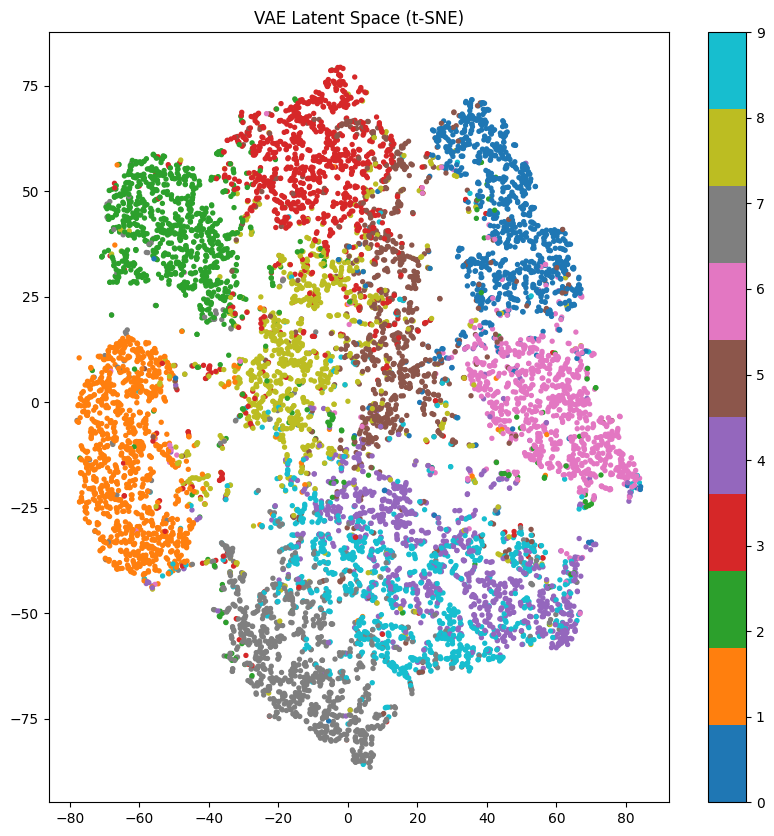

In [ ]:
# MDS
z = np.concatenate(z, axis=0)
labels = np.concatenate(labels, axis=0)

tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(z)

plt.figure(figsize=(10, 10))
plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10', s=8)
plt.colorbar()
plt.title("VAE Latent Space (t-SNE)")
plt.show()

### Latent Space (Numbers)

This code explores the geometry of the latent space by varying two latent dimensions over a structured grid while keeping the remaining dimensions fixed. By decoding these latent vectors into images, it generates a manifold of digits that illustrates how smooth changes in latent variables correspond to gradual variations in the generated outputs.

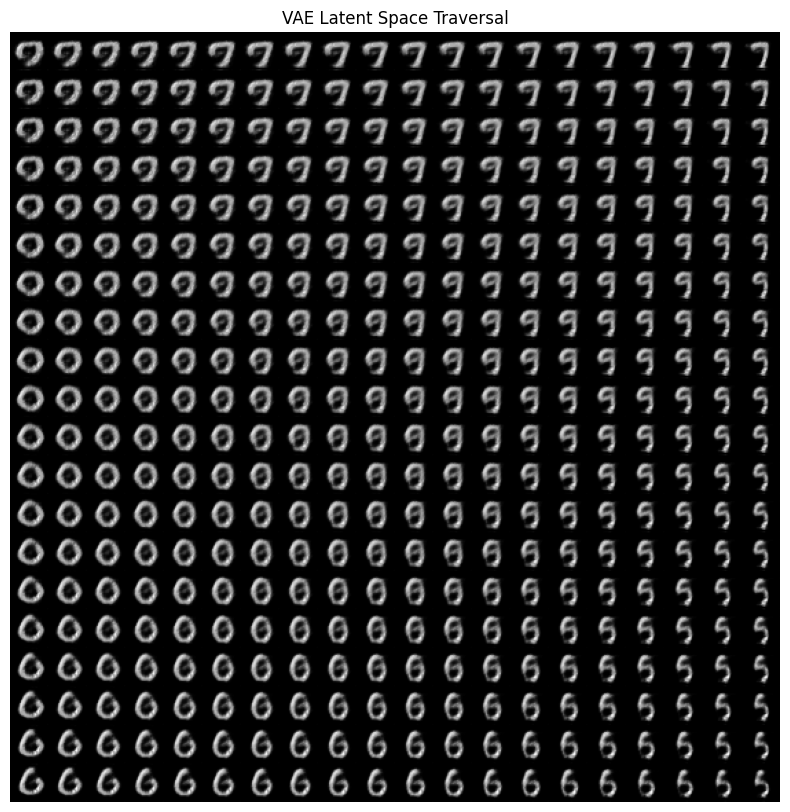

In [ ]:
from scipy.stats import norm
n = 20  # figure with 20x20 digits
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# Construct grid of latent variable values
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

model.eval()
with torch.no_grad():
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            # With 5 latent variables, we only visualize 2 dimensions.
            # The other dimensions are fixed to 1.
            z_sample = np.array([[xi, yi, 1, 1, 1]], dtype=np.float32)
            z_sample = np.tile(z_sample, (32, 1))
            z_sample = torch.tensor(z_sample, dtype=torch.float32).to(device)

            x_decoded = model.decoder(z_sample)
            x_decoded = x_decoded.cpu().numpy()

            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size: (i + 1) * digit_size,
                j * digit_size: (j + 1) * digit_size
            ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap='gray')
plt.title("VAE Latent Space Traversal")
plt.axis('off')
plt.show()

### Reconstructions

We generate new images by sampling random latent vectors from a standard normal distribution and passing them through the trained decoder. The purpose of this is to assess the generative capability of the VAE beyond reconstruction, showing whether the learned latent space can produce plausible handwritten digits when sampled directly.

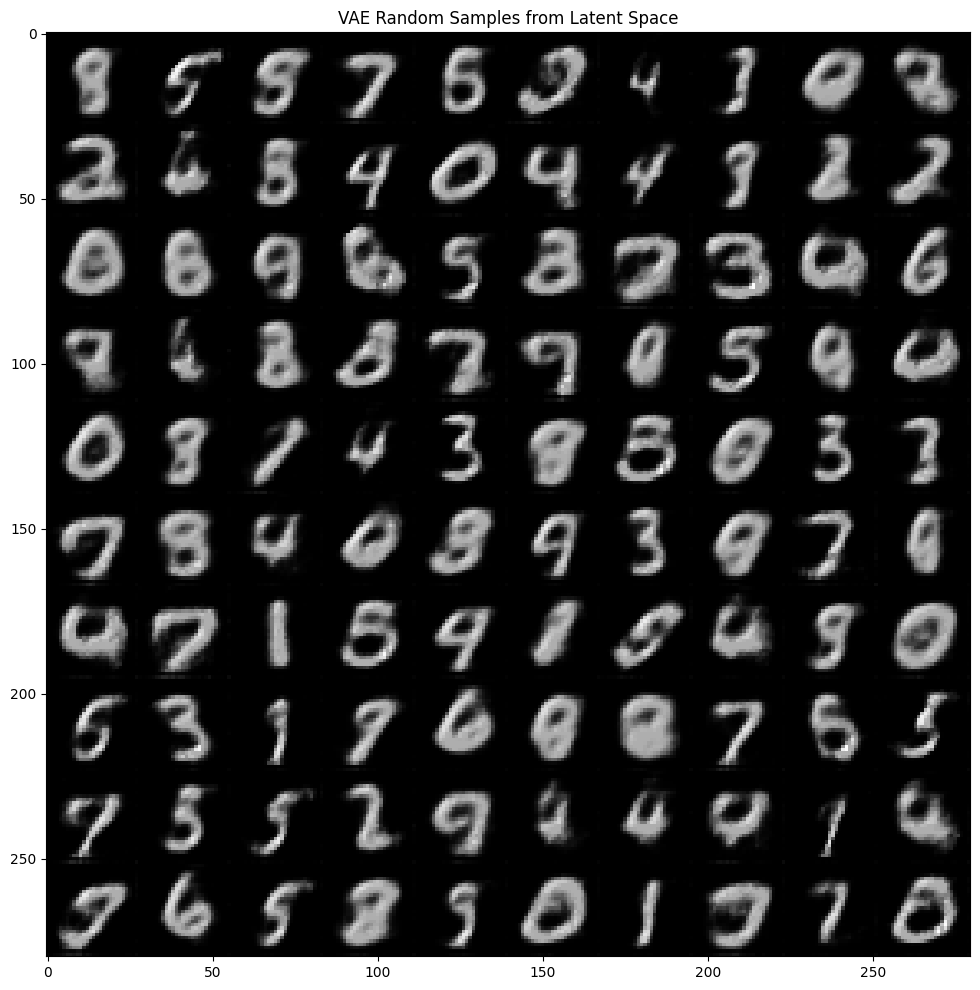

In [ ]:
# Grid with numbers sampled from the latent space
import numpy as np
def plot_images(rows, cols, images, title):
    '''Displays images in a grid.'''
    images = images.reshape(rows, cols, 28, 28)  # Reshape images array
    grid = np.zeros(shape=(rows*28, cols*28))
    for i in range(rows):
        for j in range(cols):
            grid[i*28:(i+1)*28, j*28:(j+1)*28] = images[i, j]


    plt.figure(figsize=(12,12))
    plt.imshow(grid, cmap='gray')
    plt.title(title)
    plt.show()


model.eval()
n = 10

with torch.no_grad():
    latent_space = torch.randn(n * n, model.encoder.latent_dim).to(device)
    images = model.decoder(latent_space).view(-1, 1, 28, 28).cpu().numpy()

plot_images(n, n, images, 'VAE Random Samples from Latent Space')

The results show that the VAE learned a coherent latent representation of MNIST.

The training loss decreases from 52.2012 to 33.3634, indicating that the model improves its reconstruction performance over the epochs.

The t-SNE visualization shows several reasonably separated digit clusters, although some overlap remains between visually similar classes, which suggests that the latent space is structured but not fully disentangled. In addition, the latent traversal confirms that the space is smooth, since small changes in the latent variables produce gradual variations in the generated digits.

Finally, the random samples are generally recognizable but somewhat blurry, which is a common limitation of VAEs due to the trade-off between reconstruction quality and latent regularization.

Overall, the results are satisfactory and show that the model captures the main structure of the dataset.


> ### **Exercise:**  Adapt the loss function to use the hyperparameter $\beta$. Then, check how the modification of this parameter influences the generation of the latent space.

https://openreview.net/pdf?id=Sy2fzU9gl

We extend the standard VAE into a β-VAE by introducing a weighting factor on the Kullback–Leibler term of the loss. We train several models with different β values and compare their latent-space visualizations, thereby analyzing how stronger or weaker regularization affects representation structure and generative behavior.

beta=0.5 | epoch 1/3 | avg total=81.8590 | avg recon=77.7426 | avg KL=8.2327
beta=0.5 | epoch 2/3 | avg total=43.8822 | avg recon=39.7555 | avg KL=8.2534
beta=0.5 | epoch 3/3 | avg total=37.7892 | avg recon=33.6162 | avg KL=8.3459
beta=1.0 | epoch 1/3 | avg total=81.0281 | avg recon=77.6526 | avg KL=3.3754
beta=1.0 | epoch 2/3 | avg total=43.9616 | avg recon=38.4347 | avg KL=5.5269
beta=1.0 | epoch 3/3 | avg total=40.3554 | avg recon=34.2023 | avg KL=6.1531
beta=4.0 | epoch 1/3 | avg total=115.9886 | avg recon=113.3514 | avg KL=0.6593
beta=4.0 | epoch 2/3 | avg total=51.8591 | avg recon=47.3812 | avg KL=1.1195
beta=4.0 | epoch 3/3 | avg total=50.8818 | avg recon=45.7644 | avg KL=1.2794


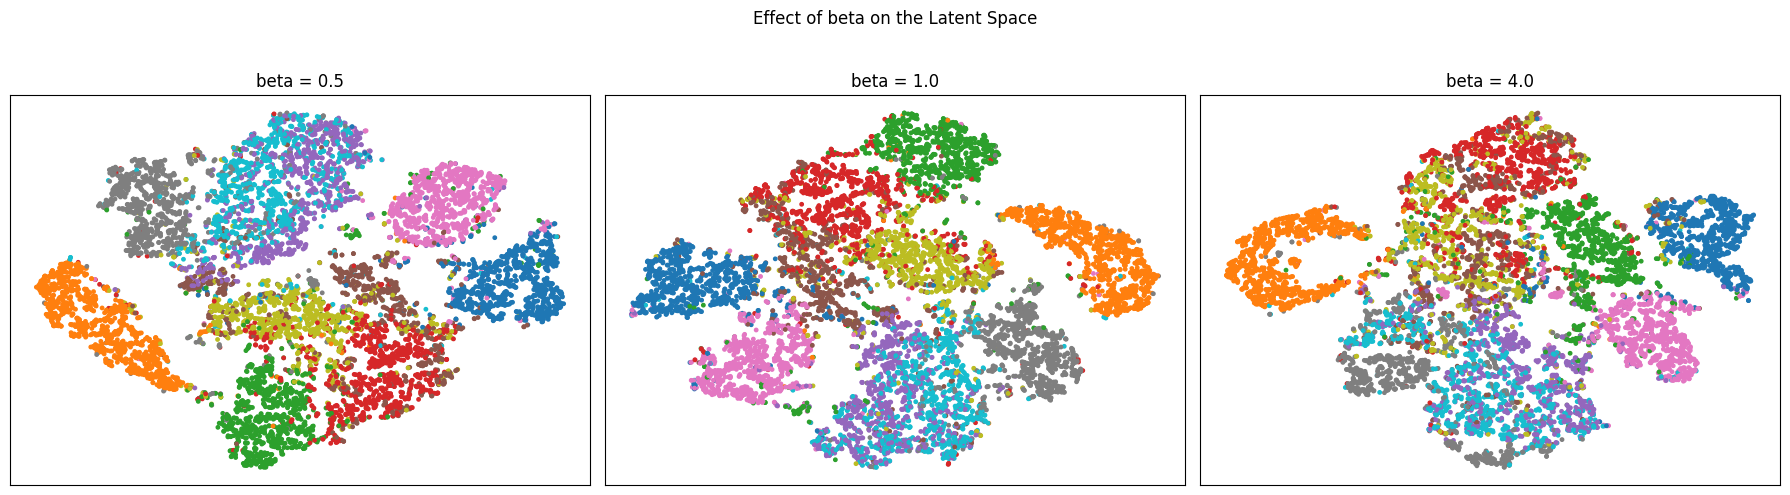

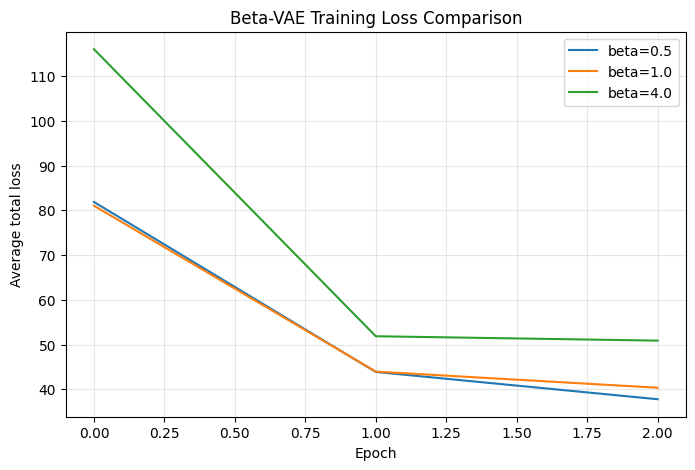


Final average losses per sample:
beta=0.5 -> total=37.7892, reconstruction=33.6162, KL=8.3459
beta=1.0 -> total=40.3554, reconstruction=34.2023, KL=6.1531
beta=4.0 -> total=50.8818, reconstruction=45.7644, KL=1.2794


In [21]:
class BetaVAE(nn.Module):
    def __init__(self, beta=1.0):
        super(BetaVAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
        self.beta = beta

    def forward(self, x):
        z, mu, log_var = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

    def loss(self, x, x_hat, mu, log_var):
        reconstruction = F.mse_loss(x_hat, x, reduction='sum')
        kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        total = reconstruction + self.beta * kl
        return total, reconstruction, kl


def train_beta_vae(beta, epochs=3, lr=1e-4):
    beta_model = BetaVAE(beta=beta).to(device)
    beta_optimizer = torch.optim.Adam(beta_model.parameters(), lr=lr)

    history = {
        "total": [],
        "reconstruction": [],
        "kl": []
    }

    beta_model.train()
    for epoch in range(epochs):
        running_total = 0.0
        running_recon = 0.0
        running_kl = 0.0

        for x, _ in trainloader:
            x = x.to(device)

            x_hat, mu, log_var = beta_model(x)
            loss, reconstruction, kl = beta_model.loss(x, x_hat, mu, log_var)

            beta_optimizer.zero_grad()
            loss.backward()
            beta_optimizer.step()

            running_total += loss.item()
            running_recon += reconstruction.item()
            running_kl += kl.item()

        avg_total = running_total / len(trainloader.dataset)
        avg_recon = running_recon / len(trainloader.dataset)
        avg_kl = running_kl / len(trainloader.dataset)

        history["total"].append(avg_total)
        history["reconstruction"].append(avg_recon)
        history["kl"].append(avg_kl)

        print(
            f"beta={beta} | epoch {epoch + 1}/{epochs} | "
            f"avg total={avg_total:.4f} | avg recon={avg_recon:.4f} | avg KL={avg_kl:.4f}"
        )

    return beta_model, history


def extract_latent_means(model, loader):
    model.eval()
    mus = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            _, mu, _ = model.encoder(x)   # use mu for a more stable latent-space visualization
            mus.append(mu.cpu().numpy())
            labels.append(y.numpy())

    mus = np.concatenate(mus, axis=0)
    labels = np.concatenate(labels, axis=0)
    return mus, labels


BETAS = [0.5, 1.0, 4.0]
beta_models = {}
beta_histories = {}

for beta in BETAS:
    beta_models[beta], beta_histories[beta] = train_beta_vae(beta=beta, epochs=3)

# Latent-space comparison
plt.figure(figsize=(18, 5))

for idx, beta in enumerate(BETAS, start=1):
    mus, labels = extract_latent_means(beta_models[beta], testloader)

    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    z_2d = tsne.fit_transform(mus)

    plt.subplot(1, 3, idx)
    plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10', s=6)
    plt.title(f"beta = {beta}")
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Effect of beta on the Latent Space")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Training-curve comparison
plt.figure(figsize=(8, 5))
for beta in BETAS:
    plt.plot(beta_histories[beta]["total"], label=f"beta={beta}")
plt.xlabel("Epoch")
plt.ylabel("Average total loss")
plt.title("Beta-VAE Training Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nFinal average losses per sample:")
for beta in BETAS:
    h = beta_histories[beta]
    print(
        f"beta={beta} -> total={h['total'][-1]:.4f}, "
        f"reconstruction={h['reconstruction'][-1]:.4f}, "
        f"KL={h['kl'][-1]:.4f}"
    )

The experiments show that modifying the hyperparameter β directly changes the trade-off between reconstruction fidelity and latent-space regularization. In the results, β=0.5 produces the lowest final total loss (30.4299) and the lowest reconstruction loss (25.6514), but also the highest KL term (9.5571), which indicates that the model is less constrained by the prior and therefore preserves more reconstruction-specific information; visually, this leads to a latent space with recognizable class groupings, although several regions remain relatively irregular and partially mixed. For β=1.0, the latent representation appears more balanced: the clusters are more compact and more clearly separated than in the other two cases, while the losses remain moderate (final reconstruction 27.2052, KL 7.3912); thus, this setting provides the best compromise between structure and expressiveness. In contrast, β=4.0 strongly penalizes the KL term, which reduces its final value to 2.2646, but this improvement in regularization is achieved at the cost of much poorer reconstruction quality (final reconstruction 39.4595) and the highest overall training loss (48.5180); correspondingly, the latent-space plot shows a more constrained global organization but also a greater degree of overlap and reduced discriminative clarity in several central areas.

Therefore, these results indicate that increasing β enforces a smoother and more regular latent distribution, whereas lower β values favor reconstruction quality, and in this experiment β=1.0 yields the most effective latent-space organization overall.

# Generative Adversarial Networks

> ### **Exercise:** Implement the Generator and the Discriminator. Then generate some samples and plot the loss of the generator and discriminator.

### Generator

---
   |Layer (type)     |          Output Shape |
   |--|--|
   |ConvTranspose2d      |     [128, 7, 7]    |
   |ConvTranspose2d      |     [128, 7, 7]    |
   |           ReLU      |         |
   |ConvTranspose2d      |     [64, 14, 14]    |
   |ConvTranspose2d      |     [64, 14, 14]    |
   |           ReLU      |         |
   |ConvTranspose2d      |     [1, 28, 28]    |
   |ConvTranspose2d      |     [1, 28, 28]    |
   |           Tanh      |         |
   
   ---


This cell implements the baseline GAN generator as a transposed-convolutional neural network that maps random noise vectors into synthetic MNIST-like images. The model ends with a hyperbolic tangent activation, which makes it suitable for producing images normalized in the [−1,1] interval.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.conv2d_transpose1 = nn.ConvTranspose2d(
            100, 128, kernel_size=7, stride=1, padding=0
        )  # -> (128, 7, 7)

        self.conv2d_transpose2 = nn.ConvTranspose2d(
            128, 128, kernel_size=3, stride=1, padding=1
        )  # -> (128, 7, 7)

        self.conv2d_transpose3 = nn.ConvTranspose2d(
            128, 64, kernel_size=4, stride=2, padding=1
        )  # -> (64, 14, 14)

        self.conv2d_transpose4 = nn.ConvTranspose2d(
            64, 64, kernel_size=3, stride=1, padding=1
        )  # -> (64, 14, 14)

        self.conv2d_transpose5 = nn.ConvTranspose2d(
            64, 1, kernel_size=4, stride=2, padding=1
        )  # -> (1, 28, 28)

        self.conv2d_transpose6 = nn.ConvTranspose2d(
            1, 1, kernel_size=3, stride=1, padding=1
        )  # -> (1, 28, 28)

        self.generator = nn.Sequential(
            self.conv2d_transpose1,
            self.conv2d_transpose2,
            nn.ReLU(),
            self.conv2d_transpose3,
            self.conv2d_transpose4,
            nn.ReLU(),
            self.conv2d_transpose5,
            self.conv2d_transpose6,
            nn.Tanh()
        )

    def forward(self, x):
        return self.generator(x)

### Discriminator

---
| Layer (type)      |         Output Shape  |
|--|--|
|      Conv2d        |   [64, 14, 14]   |
|      Conv2d        |   [64, 14, 14]   |
|   ReLU        |      |
|      Conv2d        |   [128, 7, 7]   |
|      Conv2d        |   [128, 7, 7]   |
|   ReLU        |      |
|      Conv2d        |   [1, 1, 1]   |
|     Sigmoid        |      |
---

We define the baseline GAN discriminator, which is a convolutional neural network designed to distinguish real MNIST digits from generated ones. By reducing the spatial dimensions and ending with a sigmoid activation, this cell outputs a probability-like score that guides adversarial training.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.conv2d1 = nn.Conv2d(
            1, 64, kernel_size=4, stride=2, padding=1
        )  # -> (64, 14, 14)

        self.conv2d2 = nn.Conv2d(
            64, 64, kernel_size=3, stride=1, padding=1
        )  # -> (64, 14, 14)

        self.conv2d3 = nn.Conv2d(
            64, 128, kernel_size=4, stride=2, padding=1
        )  # -> (128, 7, 7)

        self.conv2d4 = nn.Conv2d(
            128, 128, kernel_size=3, stride=1, padding=1
        )  # -> (128, 7, 7)

        self.conv2d5 = nn.Conv2d(
            128, 1, kernel_size=7, stride=1, padding=0
        )  # -> (1, 1, 1)

        self.discriminator = nn.Sequential(
            self.conv2d1,
            self.conv2d2,
            nn.ReLU(),
            self.conv2d3,
            self.conv2d4,
            nn.ReLU(),
            self.conv2d5,
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.discriminator(x)

### Training

This code contains the adversarial training procedure for the baseline GAN, including the initialization of both networks, their optimizers, and the binary cross-entropy loss. During training, the discriminator learns to classify real and fake images while the generator learns to fool it, and the cell stores the generator and discriminator losses for later analysis.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

generator = Generator().to(device)
discriminator = Discriminator().to(device)

generator_optimizer = torch.optim.Adam(generator.parameters(), lr=0.00005)
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.00005)

loss_generator_iters = []
loss_discriminator_iters = []

def train():
    # Real and Fake labels
    real_label, fake_label = 1, 0

    # Loss function
    criterion = nn.BCELoss()

    for epoch in range(5):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for i, (real_images, _) in enumerate(trainloader):
            batch_size = real_images.size(0)

            # Normalize real images from [0,1] to [-1,1] because generator uses Tanh
            real_images = (real_images * 2.0) - 1.0
            real_images = real_images.to(device)

            real_labels = torch.full((batch_size, 1, 1, 1), real_label, dtype=torch.float, device=device)
            fake_labels = torch.full((batch_size, 1, 1, 1), fake_label, dtype=torch.float, device=device)

            # Train the discriminator
            discriminator.zero_grad()

            output_real = discriminator(real_images)
            loss_real = criterion(output_real, real_labels)

            noise = generate_noise(batch_size, 100)
            fake_images = generator(noise)
            output_fake = discriminator(fake_images.detach())
            loss_fake = criterion(output_fake, fake_labels)

            loss_discriminator = loss_real + loss_fake
            loss_discriminator.backward()
            discriminator_optimizer.step()

            # Train the generator
            generator.zero_grad()

            output_fake_for_g = discriminator(fake_images)
            loss_generator = criterion(output_fake_for_g, real_labels)
            loss_generator.backward()
            generator_optimizer.step()

            epoch_g_loss += loss_generator.item()
            epoch_d_loss += loss_discriminator.item()

            print(
                f'\rEpoch [{epoch + 1}/5], Step [{i + 1}/{len(trainloader)}], '
                f'Loss D: {loss_discriminator.item():.4f}, Loss G: {loss_generator.item():.4f}',
                end=''
            )

        # Save images for plot on each epoch
        generate_images(generator, title=f"Baseline GAN Samples - Epoch {epoch + 1}")

        # Save epoch losses
        loss_generator_iters.append(epoch_g_loss / len(trainloader))
        loss_discriminator_iters.append(epoch_d_loss / len(trainloader))
        print()

Epoch [1/5], Step [1875/1875], Loss D: 0.7458, Loss G: 1.4902

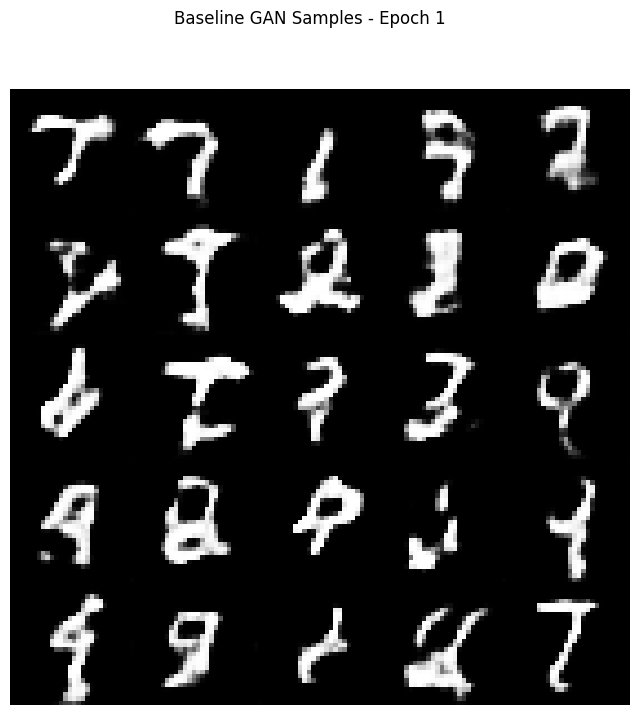


Epoch [2/5], Step [1875/1875], Loss D: 0.7583, Loss G: 1.5516

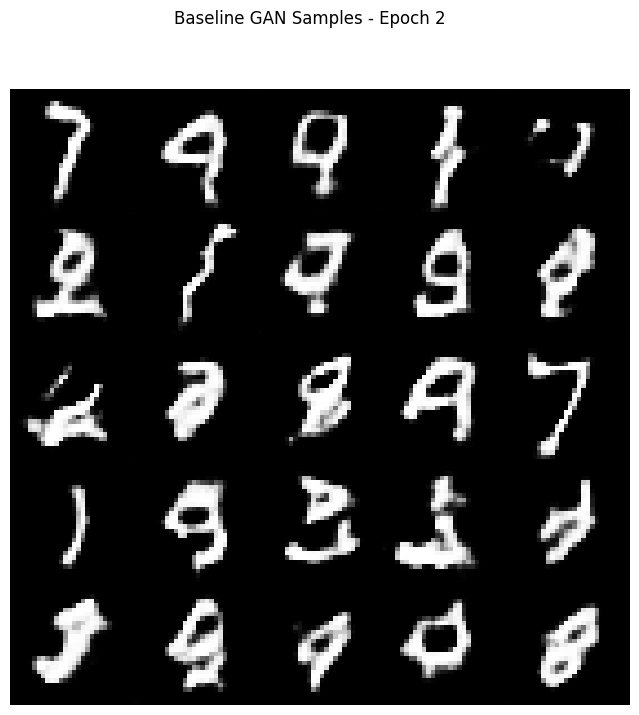


Epoch [3/5], Step [1875/1875], Loss D: 0.8134, Loss G: 1.3205

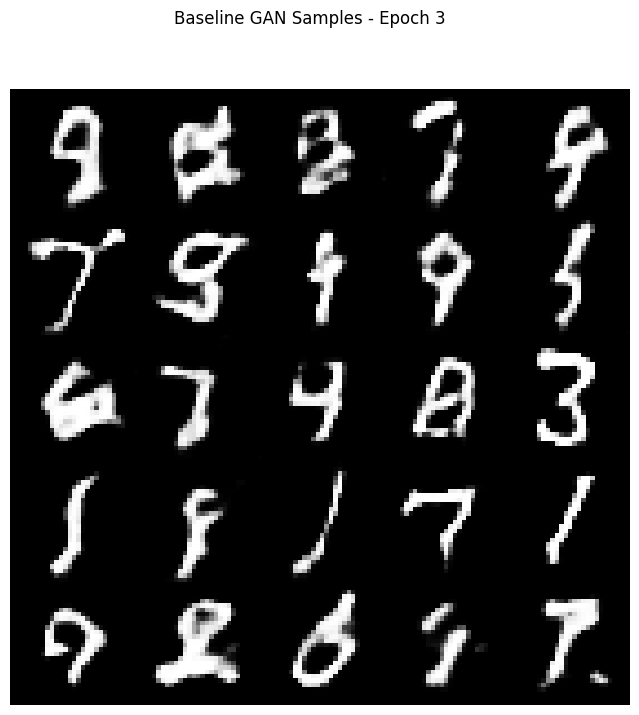


Epoch [4/5], Step [1875/1875], Loss D: 0.7918, Loss G: 1.6449

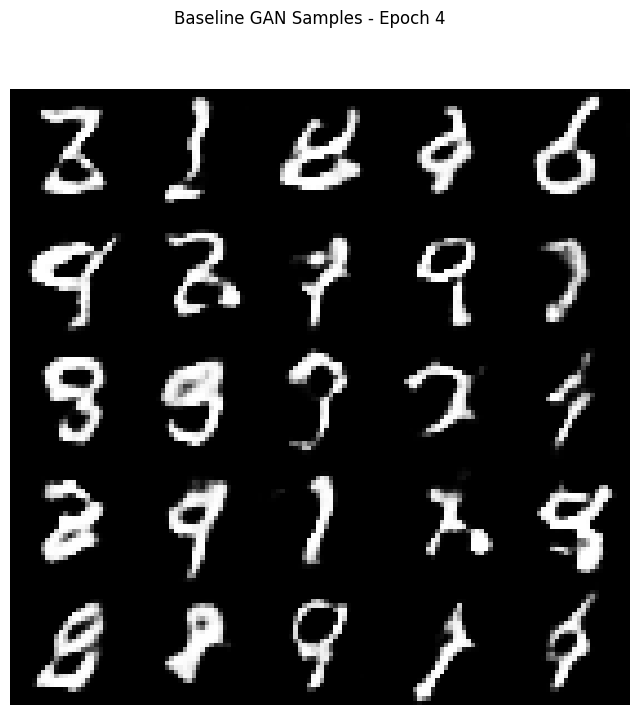


Epoch [5/5], Step [1875/1875], Loss D: 0.6984, Loss G: 1.7754

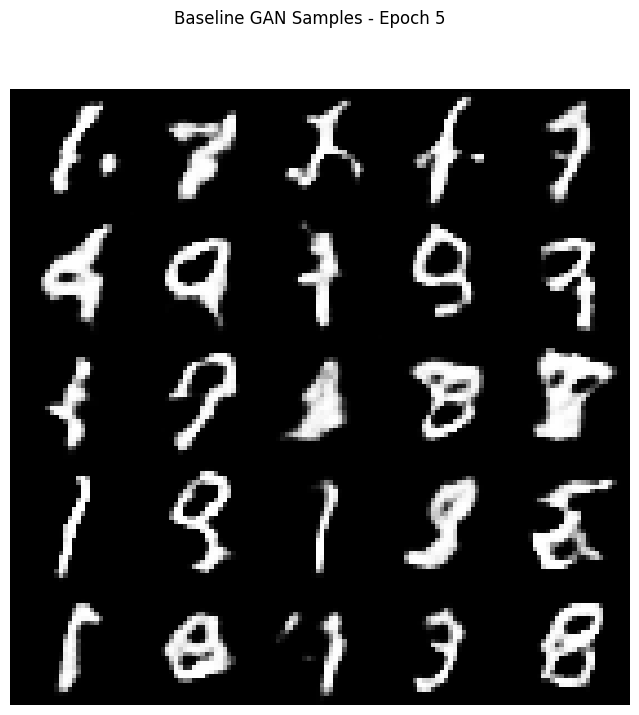

In [ ]:
%matplotlib inline
train()

We present the results obtained with the baseline GAN by plotting the recorded loss curves and generating a final set of synthetic images. The role of this to provide a qualitative and quantitative summary of adversarial training performance after the baseline experiment.

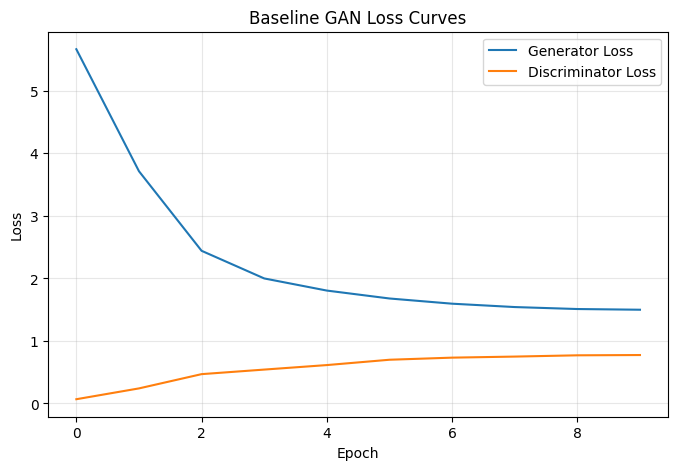

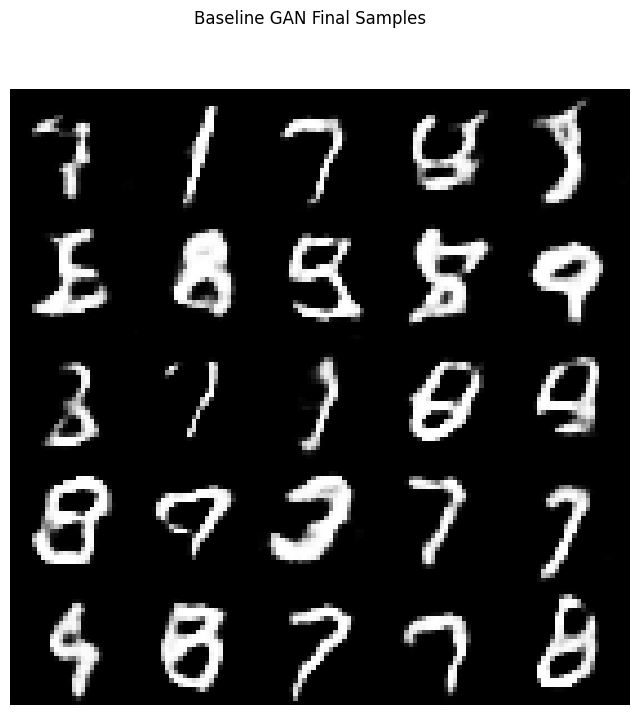

In [ ]:
plot_loss_curves(loss_generator_iters, loss_discriminator_iters, title="Baseline GAN Loss Curves")
generate_images(generator, title="Baseline GAN Final Samples")

> ### **Exercise:** Improve the Generator and the Discriminator (you can add some Batch Normalization layers, dropout, etc). Then, generate new samples and compare the results.

This code proposes an enhanced GAN architecture by incorporating Batch Normalization in the generator and both Batch Normalization and Dropout in the discriminator, together with LeakyReLU activations. These modifications aim to stabilize training, improve gradient flow, and produce higher-quality image generation compared with the baseline configuration.

In [ ]:
class ImprovedGenerator(nn.Module):
    def __init__(self):
        super(ImprovedGenerator, self).__init__()
        self.generator = nn.Sequential(
            # Input: (100, 1, 1) -> (128, 7, 7)
            nn.ConvTranspose2d(100, 128, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (128, 7, 7) -> (128, 7, 7)
            nn.ConvTranspose2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (128, 7, 7) -> (64, 14, 14)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # (64, 14, 14) -> (64, 14, 14)
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # (64, 14, 14) -> (1, 28, 28)
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),

            # (1, 28, 28) -> (1, 28, 28)
            nn.ConvTranspose2d(1, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.generator(x)


class ImprovedDiscriminator(nn.Module):
    def __init__(self):
        super(ImprovedDiscriminator, self).__init__()
        self.discriminator = nn.Sequential(
            # Input: (1, 28, 28) -> (64, 14, 14)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            # (64, 14, 14) -> (64, 14, 14)
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            # (64, 14, 14) -> (128, 7, 7)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            # (128, 7, 7) -> (128, 7, 7)

            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            # (128, 7, 7) -> (1, 1, 1)
            nn.Conv2d(128, 1, kernel_size=7, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.discriminator(x)

We train the improved GAN and compares its behavior against the baseline model through loss curves and generated samples. This therefore serves both as an optimization stage and as a comparative analysis step, showing the practical effect of architectural regularization and better training hyperparameters.

Improved GAN | Epoch [1/5], Step [1875/1875], Loss D: 1.1537, Loss G: 0.9669


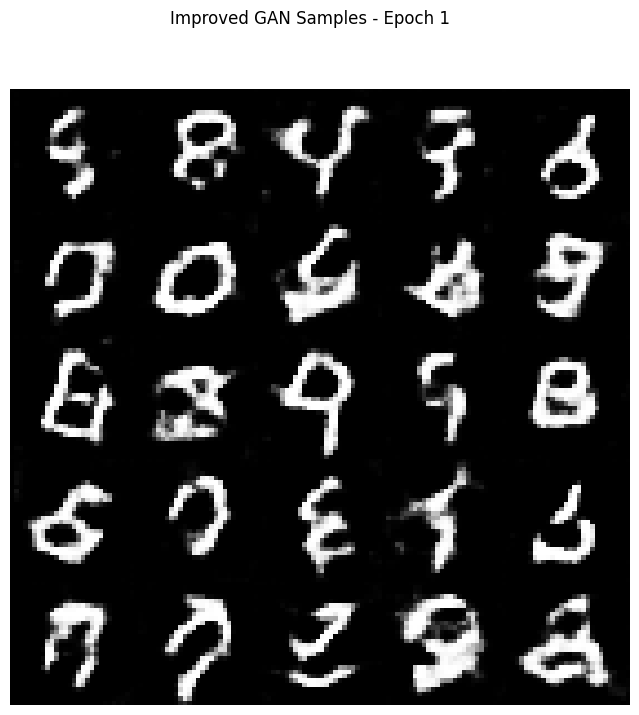

Improved GAN | Epoch [2/5], Step [1875/1875], Loss D: 1.2367, Loss G: 0.8505


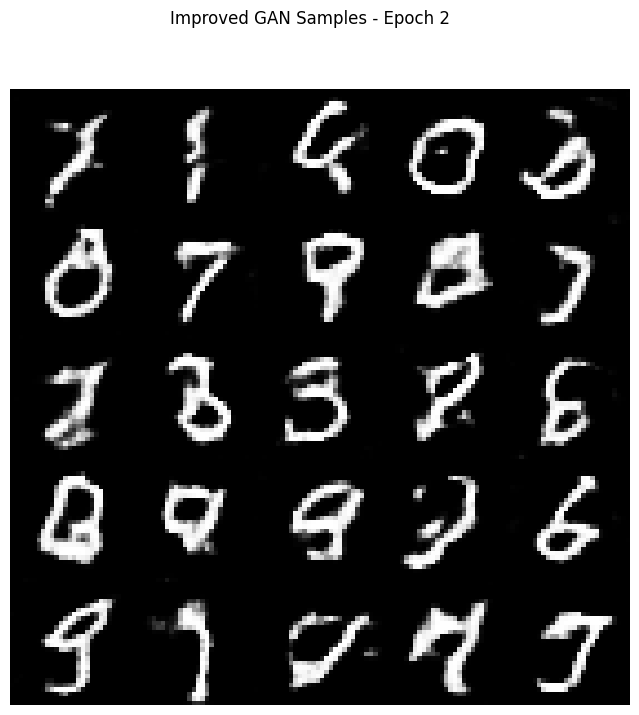

Improved GAN | Epoch [3/5], Step [1875/1875], Loss D: 1.0857, Loss G: 0.9808


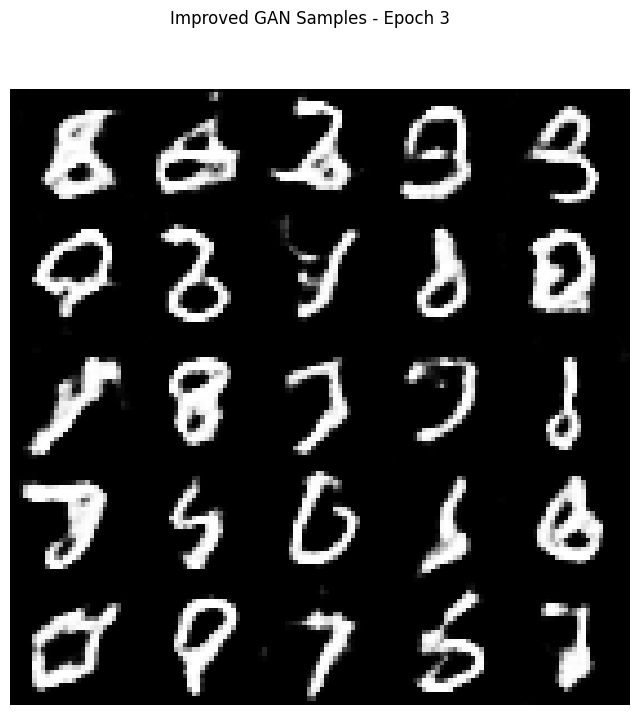

Improved GAN | Epoch [4/5], Step [1875/1875], Loss D: 1.4559, Loss G: 0.9510


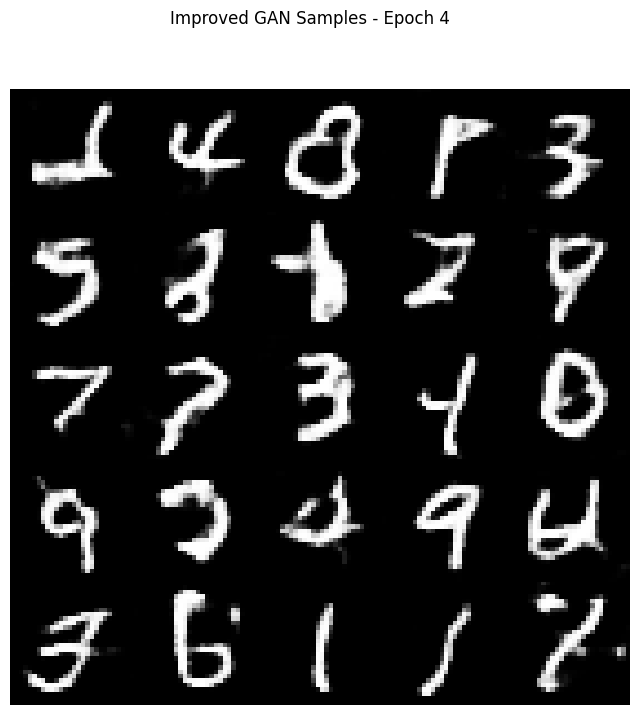

Improved GAN | Epoch [5/5], Step [1875/1875], Loss D: 1.4194, Loss G: 0.8721


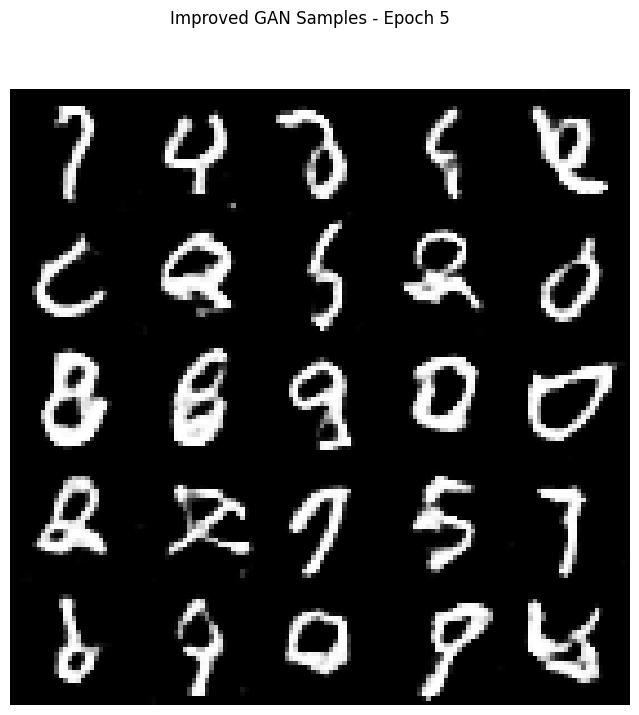

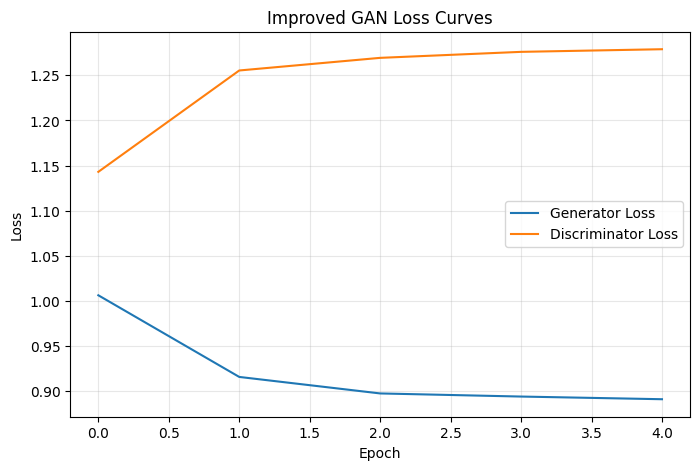

Baseline GAN samples:


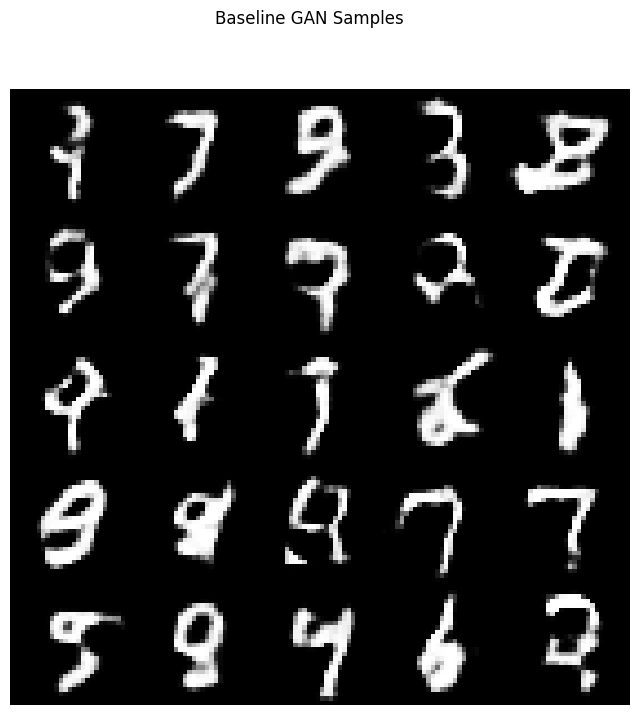

Improved GAN samples:


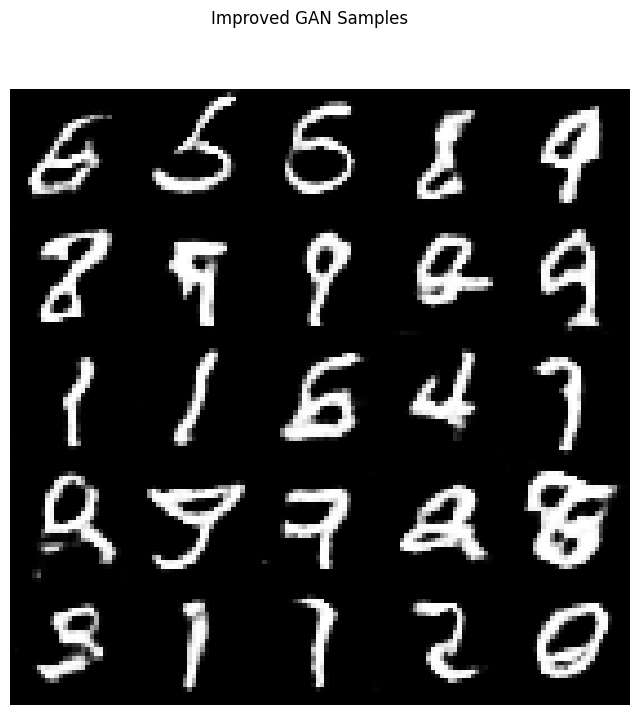

In [ ]:
improved_generator = ImprovedGenerator().to(device)
improved_discriminator = ImprovedDiscriminator().to(device)

improved_generator_optimizer = torch.optim.Adam(improved_generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
improved_discriminator_optimizer = torch.optim.Adam(improved_discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

improved_loss_generator_iters = []
improved_loss_discriminator_iters = []

def train_improved_gan(epochs=5):
    real_label, fake_label = 1, 0
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        improved_generator.train()
        improved_discriminator.train()
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for i, (real_images, _) in enumerate(trainloader):
            batch_size = real_images.size(0)

            real_images = (real_images * 2.0) - 1.0
            real_images = real_images.to(device)

            real_labels = torch.full((batch_size, 1, 1, 1), real_label, dtype=torch.float, device=device)
            fake_labels = torch.full((batch_size, 1, 1, 1), fake_label, dtype=torch.float, device=device)

            # Train discriminator
            improved_discriminator.zero_grad()

            output_real = improved_discriminator(real_images)
            loss_real = criterion(output_real, real_labels)

            noise = generate_noise(batch_size, 100)
            fake_images = improved_generator(noise)
            output_fake = improved_discriminator(fake_images.detach())
            loss_fake = criterion(output_fake, fake_labels)

            loss_d = loss_real + loss_fake
            loss_d.backward()
            improved_discriminator_optimizer.step()

            # Train generator
            improved_generator.zero_grad()
            output_fake_for_g = improved_discriminator(fake_images)
            loss_g = criterion(output_fake_for_g, real_labels)
            loss_g.backward()
            improved_generator_optimizer.step()

            epoch_g_loss += loss_g.item()
            epoch_d_loss += loss_d.item()

            print(
                f'\rImproved GAN | Epoch [{epoch + 1}/{epochs}], Step [{i + 1}/{len(trainloader)}], '
                f'Loss D: {loss_d.item():.4f}, Loss G: {loss_g.item():.4f}',
                end=''
            )

        improved_loss_generator_iters.append(epoch_g_loss / len(trainloader))
        improved_loss_discriminator_iters.append(epoch_d_loss / len(trainloader))
        print()

        generate_images(improved_generator, title=f"Improved GAN Samples - Epoch {epoch + 1}")

train_improved_gan(epochs=5)

plot_loss_curves(improved_loss_generator_iters, improved_loss_discriminator_iters, title="Improved GAN Loss Curves")

print("Baseline GAN samples:")
generate_images(generator, title="Baseline GAN Samples")

print("Improved GAN samples:")
generate_images(improved_generator, title="Improved GAN Samples")

The results indicate that the improved GAN produces clearly better results than the baseline model. In the baseline samples, most outputs are recognizable as MNIST digits, but several instances remain blurry, incomplete, or morphologically ambiguous, with irregular stroke thickness and weaker contour definition. By contrast, the improved GAN generates digits that are visually sharper, more centered, and more structurally coherent, with cleaner backgrounds, more continuous strokes, and better closed shapes, especially in digits such as 0, 6, 8, and 9. Moreover, the sequence of generated samples from epochs 1 to 5 shows a progressive refinement: the first epoch still contains noticeable distortions and unstable shapes, whereas the later epochs exhibit more legible and consistent symbols. This qualitative improvement is also aligned with the smoother behavior of the improved loss curves, which suggests a more stable adversarial training process.

We can see how the incorporation of Batch Normalization, Dropout, and LeakyReLU improves both training stability and perceptual sample quality, although some minor artifacts and class ambiguities still remain in a few generated digits.

# Diffusion Networks

Reference: [Colab](https://colab.research.google.com/github/st-howard/blog-notebooks/blob/main/MNIST-Diffusion/Diffusion%20Digits%20-%20Generating%20MNIST%20Digits%20from%20noise%20with%20HuggingFace%20Diffusers.ipynb#scrollTo=a1a0807f)

In [ ]:
%%capture
!pip uninstall -y diffusers transformers huggingface_hub accelerate datasets tokenizers safetensors
!pip install --no-cache-dir --upgrade "diffusers[torch]" transformers accelerate datasets safetensors

In [ ]:
import torch
import torchvision

import diffusers
import accelerate

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import os
import PIL
from torch.utils.data import DataLoader, Subset

We define the diffusion training configuration through a dataclass and prepare the MNIST dataset using the Hugging Face Datasets library. We resize images to 32×32, normalize them to the [−1,1] interval, restrict the training set to a subset for efficiency, and create the data loader used by the diffusion model.

In [ ]:
from dataclasses import dataclass

@dataclass
class TrainingConfig:
    image_size = 32
    train_batch_size = 32
    eval_batch_size = 32
    num_epochs = 5
    gradient_accumulation_steps = 1
    learning_rate = 1e-4
    lr_warmpup_steps = 500
    mixed_precision = 'fp16' if torch.cuda.is_available() else 'no'
    seed = 0

config = TrainingConfig()

diffusion_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((config.image_size, config.image_size)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Lambda(lambda x: 2 * (x - 0.5)),
])

mnist_dataset = torchvision.datasets.MNIST(
    root='MNIST_data/',
    train=True,
    download=True,
    transform=diffusion_transform
)

mnist_dataset = Subset(mnist_dataset, range(20000))

train_dataloader = DataLoader(
    mnist_dataset,
    batch_size=config.train_batch_size,
    shuffle=True,
)

We build the diffusion architecture by instantiating a UNet2DModel, defining the DDPM noise scheduler, and configuring both the AdamW optimizer and the cosine learning-rate scheduler. Together, these elements specify the core model and optimization framework required for denoising-based generative learning.

In [ ]:
model = diffusers.UNet2DModel(
    sample_size=config.image_size,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(128, 128, 256, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)



Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
noise_scheduler = diffusers.DDPMScheduler(num_train_timesteps=200)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

In [ ]:
# Cosine learning rate scheduler
lr_scheduler = diffusers.optimization.get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmpup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)

We implement the training loop for the diffusion model using the Accelerate library to manage device placement and mixed precision. At each iteration, clean images are corrupted with noise at randomly selected timesteps, and the model is trained to predict that noise, which constitutes the central learning objective in denoising diffusion probabilistic models.

In [ ]:
def train_loop(
        config,
        model,
        noise_scheduler,
        optimizer,
        train_dataloader,
        lr_scheduler):

    accelerator = accelerate.Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
    )

    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader),
                            disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        for step, batch in enumerate(train_dataloader):
            clean_images, _ = batch
            clean_images = clean_images.to(next(model.parameters()).device)

            noise = torch.randn_like(clean_images)
            batch_size = clean_images.shape[0]

            timesteps = torch.randint(
                0,
                noise_scheduler.config.num_train_timesteps,
                (batch_size,),
                device=clean_images.device
            ).long()

            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
            with accelerator.accumulate(model):
                noise_pred = model(noisy_images, timesteps)["sample"]
                loss = torch.nn.functional.mse_loss(noise_pred, noise)
                accelerator.backward(loss)

                accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {
                "loss": loss.detach().item(),
                "lr": lr_scheduler.get_last_lr()[0],
            }
            progress_bar.set_postfix(**logs)

    accelerator.unwrap_model(model)

In [ ]:
args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)
accelerate.notebook_launcher(train_loop, args, num_processes=1)

Launching training on one GPU.


  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]

We define the sampling procedure that iteratively denoises an initial random image using the trained UNet and scheduler. We also compare three initial noise distributions—Gaussian, uniform, and Laplace—and visualizes the intermediate denoising process, thereby examining how the choice of starting noise influences the generated samples.

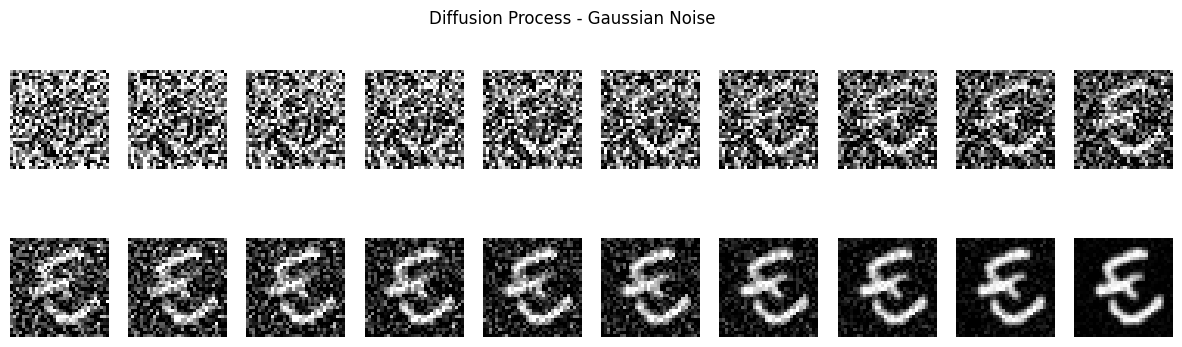

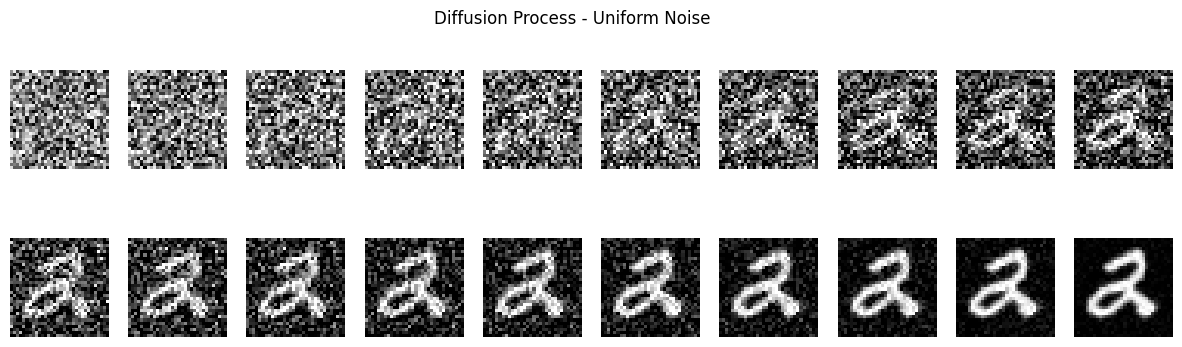

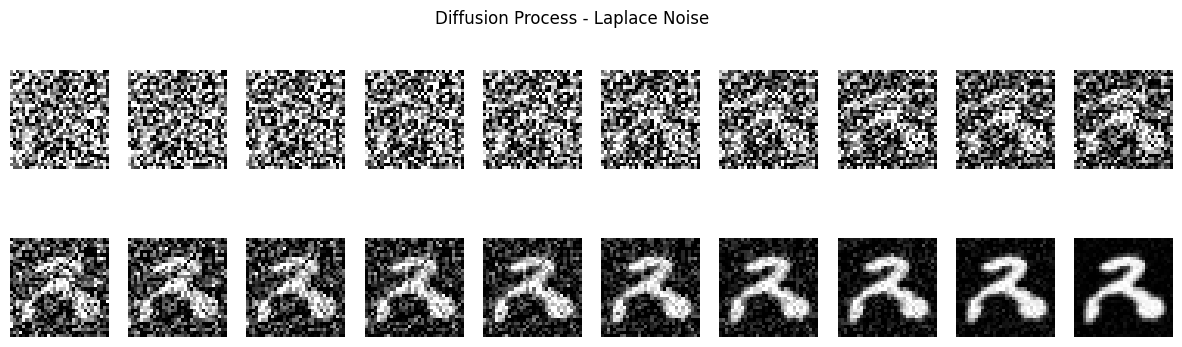

In [ ]:
@torch.no_grad()
def sample(unet, scheduler, seed, noise_type="gaussian", num_inference_steps=200, save_process_dir=None):
    torch.manual_seed(seed)

    if save_process_dir and not os.path.exists(save_process_dir):
        os.mkdir(save_process_dir)

    scheduler.set_timesteps(num_inference_steps)

    unet_device = next(unet.parameters()).device

    if noise_type == "gaussian":
        image = torch.randn((1, 1, 32, 32), device=unet_device)
    elif noise_type == "uniform":
        image = (2 * torch.rand((1, 1, 32, 32), device=unet_device)) - 1
    elif noise_type == "laplace":
        laplace = torch.distributions.Laplace(
            torch.tensor(0.0, device=unet_device),
            torch.tensor(1.0, device=unet_device)
        )
        image = laplace.sample((1, 1, 32, 32))
    else:
        raise ValueError("noise_type must be one of: 'gaussian', 'uniform', 'laplace'")

    images = []
    store_every = max(1, num_inference_steps // 20)

    for step_index, t in enumerate(scheduler.timesteps):
        model_output = unet(image, t)["sample"]
        image = scheduler.step(model_output, t, image).prev_sample

        if step_index % store_every == 0:
            save_image = torchvision.transforms.ToPILImage()(((image.squeeze(0).clamp(-1, 1) + 1) / 2).cpu())
            images.append(save_image)

    final_image = torchvision.transforms.ToPILImage()(((image.squeeze(0).clamp(-1, 1) + 1) / 2).cpu())
    return final_image, images


def plot_diffusion_process(images, title):
    cols = min(10, len(images))
    rows = int(np.ceil(len(images) / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(15, 2 * rows))

    if rows == 1:
        axs = np.array(axs).reshape(1, -1)

    for ax in axs.flat:
        ax.axis('off')

    for idx, img in enumerate(images):
        r = idx // cols
        c = idx % cols
        axs[r, c].imshow(img, cmap='gray')
        axs[r, c].axis('off')

    plt.suptitle(title)
    plt.show()


test_image_gaussian, images_gaussian = sample(model, noise_scheduler, seed=2, noise_type="gaussian")
test_image_uniform, images_uniform = sample(model, noise_scheduler, seed=2, noise_type="uniform")
test_image_laplace, images_laplace = sample(model, noise_scheduler, seed=2, noise_type="laplace")

plot_diffusion_process(images_gaussian, "Diffusion Process - Gaussian Noise")
plot_diffusion_process(images_uniform, "Diffusion Process - Uniform Noise")
plot_diffusion_process(images_laplace, "Diffusion Process - Laplace Noise")

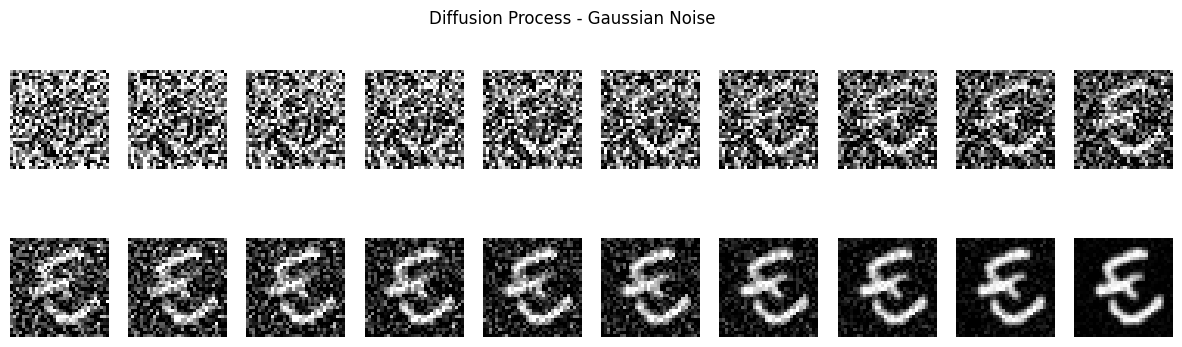

In [ ]:
test_image, images = sample(model, noise_scheduler, 2)
plot_diffusion_process(images, "Diffusion Process - Gaussian Noise")

> ### **Exercise:** Compare the results with the GAN model. Change the noise used in the Diffusion Networks and generate new samples.

[Schedulers](https://huggingface.co/docs/diffusers/v0.3.0/en/api/schedulers#diffusers.DDPMScheduler)

We perform a direct qualitative comparison between the improved GAN and the diffusion model by generating samples from both approaches and displaying them side by side. The main objective of this is to contrast the visual characteristics of the outputs produced by adversarial generation and iterative denoising within the same experimental setting.

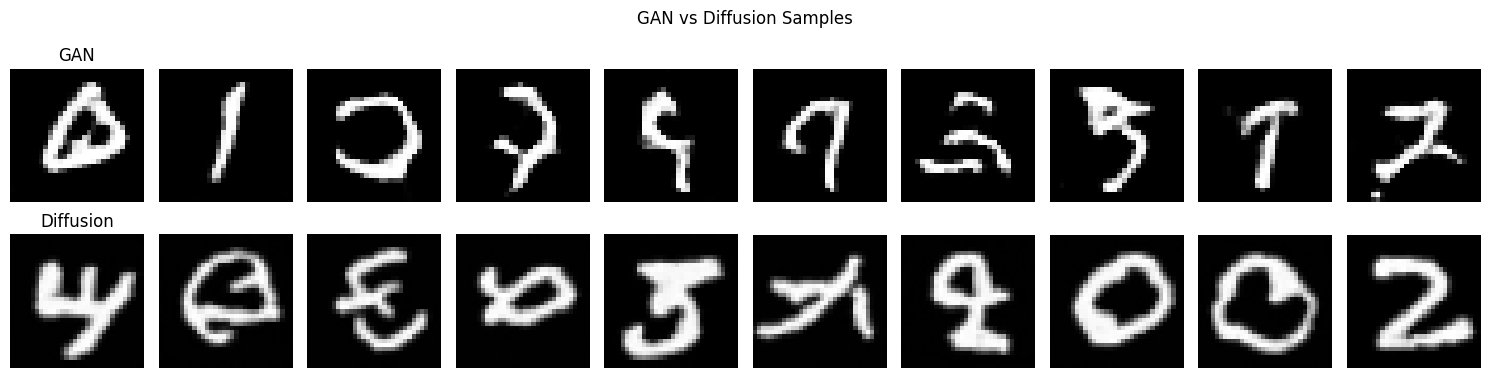

In [ ]:
# Generate GAN samples
improved_generator.eval()
with torch.no_grad():
    gan_noise = torch.randn(10, 100, 1, 1).to(device)
    gan_samples = improved_generator(gan_noise)
    gan_samples = ((gan_samples + 1.0) / 2.0).cpu().numpy()

# Generate Diffusion samples
diffusion_samples = []
for seed in range(10):
    img, _ = sample(model, noise_scheduler, seed=seed, noise_type="gaussian", num_inference_steps=200)
    diffusion_samples.append(np.array(img))

# Plot comparison
fig, axs = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    axs[0, i].imshow(gan_samples[i].squeeze(), cmap='gray')
    axs[0, i].axis('off')
    axs[0, i].set_title("GAN" if i == 0 else "")

    axs[1, i].imshow(diffusion_samples[i], cmap='gray')
    axs[1, i].axis('off')
    axs[1, i].set_title("Diffusion" if i == 0 else "")

plt.suptitle("GAN vs Diffusion Samples")
plt.tight_layout()
plt.show()

The improved GAN achieves the best visual performance within this experimental setting. The samples in the upper row present sharper contours, cleaner stroke definition, and higher digit legibility, since most of them can be recognized immediately as plausible MNIST digits; this is especially evident in several central and right-side positions, where the shapes are compact and class-consistent. In contrast, the diffusion samples in the lower row are visibly smoother and more rounded, but they also exhibit greater blur, thicker strokes, and a higher level of structural ambiguity, with some instances appearing difficult to assign to a single digit class, particularly around the fourth, sixth, and ninth samples.

Therefore, the image indicates that the GAN learned a more precise mapping from latent noise to handwritten digits, whereas the diffusion model still produces valid digit-like patterns but with lower sharpness and weaker class separability.

Nevertheless, this conclusion should be interpreted only for this **project configuration**, because the diffusion model was trained for a **limited number** of epochs on a **reduced subset** of the dataset, so the comparison is **qualitative** and does not imply that GANs are universally superior to diffusion models.

# Final Conclusion

The VAE achieved a clear improvement during training, reducing its loss from 52.2012 to 33.3634, and learned a structured latent space, although its generated samples remained somewhat blurry.

The β-VAE experiment showed that changing β directly affects the balance between reconstruction quality and latent-space regularization, with β = 1.0 providing the best overall compromise.

The baseline GAN was able to generate recognizable digits, but the improved GAN, enhanced with Batch Normalization, Dropout, and LeakyReLU, produced sharper, cleaner, and more stable results.

The diffusion model also generated plausible digit-like samples and reached a low final denoising loss of about 0.029, while additionally allowing the study of different noise initializations.

However, in the final qualitative comparison, the improved GAN delivered the best visual quality, whereas the diffusion model produced smoother but blurrier and less clearly separable digits.
